# Necessary Imports and Load
- The main data loading is handled by the `src/data_loader.py`

In [8]:
import sys
sys.path.append('..')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_loader import DataLoader
loader = DataLoader("../dataset/ml-1m/")
ratings = loader.load_rating()
movies = loader.load_movies()
users = loader.load_users()
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
print("Ratings:", ratings.shape)
print(ratings.head())

Ratings: (1000209, 4)
   user_id  movie_id  rating           timestamp
0        1      1193       5 2000-12-31 22:12:40
1        1       661       3 2000-12-31 22:35:09
2        1       914       3 2000-12-31 22:32:48
3        1      3408       4 2000-12-31 22:04:35
4        1      2355       5 2001-01-06 23:38:11


# Basic Stats

In [9]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
observed_ratings = len(ratings)
possible_ratings = n_users * n_movies
density = observed_ratings/possible_ratings
print(n_users)
print(n_movies)
print(observed_ratings)
print(possible_ratings)
print(density)
print(f"{density:.4%}")

stats = pd.DataFrame({
    'Metric': ["Users", "Movies", "Ratings", "Density"],
    'Value': [n_users, n_movies, observed_ratings, f'{density:.4%}']
})
print(stats)
stats.to_csv("../results/dataset_stats.csv", index=False)

6040
3706
1000209
22384240
0.044683625622312845
4.4684%
    Metric    Value
0    Users     6040
1   Movies     3706
2  Ratings  1000209
3  Density  4.4684%


# User Bias (Rating Bias) (Optimistic vs Pessimistic)
Are user inherently generous or strict?. This show the Average ratings per user.
suppose A rate 5 5 4 5 -> mean is 4.75
another B rate 2 2 3 1 -> mean is 2.0
for the same movie **Movie X** 
- A gives 4 and B gives 2
Without **normalization**:
model thinks: A likes more
but in reality:
A rates everything high.
B rates everything low.
hence $$r'_{ui} =r_{ui}​−μ_u$$ subtract user average.

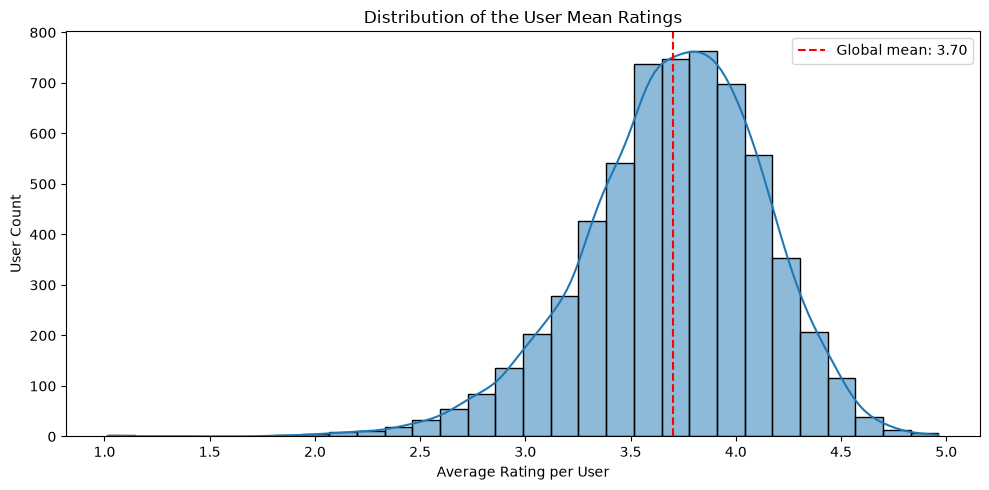

Optimistic users (mean >= 4.0): 1544
Pessimistic users (mean <= 2.5): 58


In [10]:
user_mean = ratings.groupby("user_id")["rating"].mean()
plt.figure(figsize=(10,5))
sns.histplot(user_mean, bins=30, kde=True)
plt.axvline(user_mean.mean(), color='red', linestyle='--', label=f'Global mean: {user_mean.mean():.2f}')
plt.title("Distribution of the User Mean Ratings")
plt.xlabel("Average Rating per User")
plt.ylabel("User Count")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/fig_01_user_bias.png", dpi=300, bbox_inches='tight')
plt.show()
# Print extremes for text
print("Optimistic users (mean >= 4.0):", (user_mean >= 4.0).sum())
print("Pessimistic users (mean <= 2.5):", (user_mean <= 2.5).sum())

# Long Tail/Movie Popularity Distribution
`groupby("movieId")` looks at the ratings and group all the rows as movieId and `size` counts how many rows(ratings) are in each movies bucket and sorting the counts from the highest to lowest.

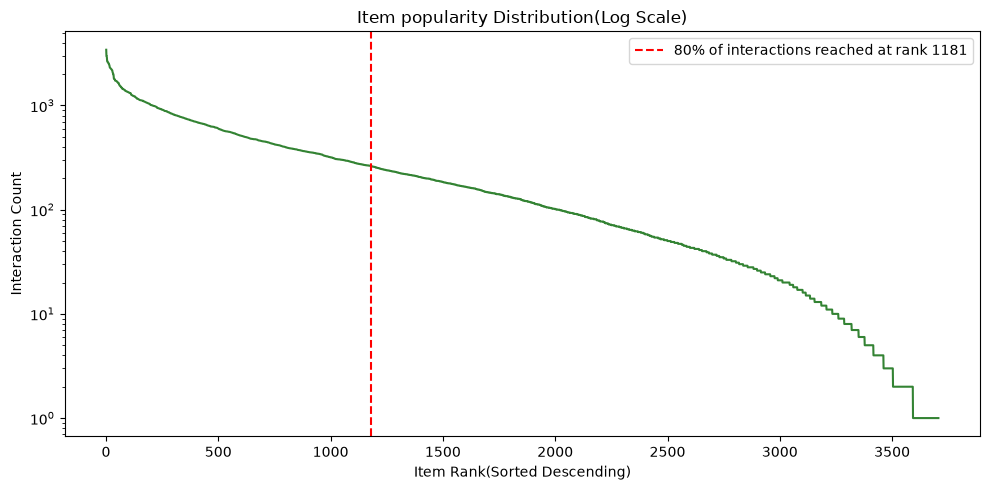

Top 1181 movies covers 80% of ratings


In [12]:
movie_counts = ratings["movie_id"].value_counts().sort_values(ascending=False).reset_index()
movie_counts.columns = ["movie_id", "count"]

cum_pct = movie_counts["count"].cumsum() / movie_counts["count"].sum()
threshold_80 = (cum_pct <= 0.80).sum()

plt.figure(figsize=(10,5))
plt.plot(range(1, len(movie_counts)+1), movie_counts["count"], color="darkgreen", alpha=0.8) 
plt.axvline(x=threshold_80, color='red', linestyle='--', label=f'80% of interactions reached at rank {threshold_80}')

plt.yscale("log")
plt.title("Item popularity Distribution(Log Scale)")
plt.xlabel("Item Rank(Sorted Descending)")
plt.ylabel("Interaction Count")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/fig_02_long_tail.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Top {threshold_80} movies covers 80% of ratings")

# Cold Start/Cold Entities(pre-filter check)

In [13]:
user_counts = ratings["user_id"].value_counts()
movie_counts = ratings["movie_id"].value_counts()
cold_users = (user_counts < 20).sum()
cold_items = (movie_counts < 20).sum()

print(f"Users with <20 ratings (cold users): {cold_users}")
print(f"Movies with <20 ratings (cold items): {cold_items}")

Users with <20 ratings (cold users): 0
Movies with <20 ratings (cold items): 663
